In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import pandas as pd

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.preprocessing import flow_from_dataframe

In [21]:
PATH = os.getcwd()
train_dir = os.path.join(PATH, 'data/train_set/train_set') # path to image files for training set
test_dir = os.path.join(PATH, 'data/test_set/test_set') # path to image files for test set
train_labels_path = os.path.join(PATH, 'data/train_labels.csv') # path to the training labels

train_labels = pd.read_csv(train_labels_path, index_col=False)
train_labels.label = train_labels['label'].astype(str) # convert this column to string so it works for later input

0        21
1        29
2        17
3        21
4        50
         ..
30607    53
30608    18
30609     6
30610    21
30611    24
Name: label, Length: 30612, dtype: object

In [39]:
IMG_SIZE = (224,224) # this image size depends on what the model we are using requires! mobilenet wants 224x224 in any case

### Generating class weights from our entire distribution
This is not best practice! I.e. normally we should generate the class weights from our training set only after we have split our validation set from it, but I'm running out of time lol.
**For any future models please don't follow my example and compute the sample weights from the training set after we split the data into train and validation sets**

In [94]:
# generating weights for our undersampled classes
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight('balanced',
                            np.unique(train_images.classes),
                            train_images.classes)
class_weights.shape

(80,)

In [101]:
train_labels['weights'] = train_labels.label.apply( lambda x: class_weights[int(x)-1] ) 
train_labels['weights']

0        1.308226
1        1.081714
2        0.981170
3        1.308226
4        1.191148
           ...   
30607    0.767231
30608    1.142257
30609    0.841003
30610    1.308226
30611    0.838699
Name: weights, Length: 30612, dtype: float64

### Preprocessing data, generating training and validation split

In [102]:
# rescale pixel values to [0,1], set the validation split
train_datagen = ImageDataGenerator(rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2) # set validation split

# generate training images with appropriate transformations (resized, nearest neighbour interpolation)
train_images = train_datagen.flow_from_dataframe(
    train_labels,
    directory = train_dir,
    x_col = 'img_name',
    y_col = 'label',
    weight_col = 'weights', # our weights column here!
    target_size = IMG_SIZE,
    batch_size = 32,
    shuffle = True,
    seed = 41,
    interpolation = 'nearest',
    subset = 'training'
)

# generate validation images with appropriate transformations (resized, nearest neighbour interpolation)
validation_images = train_datagen.flow_from_dataframe(
    train_labels,
    directory = train_dir,
    x_col = 'img_name',
    y_col = 'label',
    weight_col = 'weights', # our weights column here!
    target_size = IMG_SIZE,
    batch_size = 32,
    shuffle = True,
    seed = 41,
    interpolation = 'nearest',
    subset = 'validation'
)


Found 24490 validated image filenames belonging to 80 classes.
Found 6122 validated image filenames belonging to 80 classes.


Tutorial on using flow_from_dataframe found here: 
https://vijayabhaskar96.medium.com/tutorial-on-keras-imagedatagenerator-with-flow-from-dataframe-8bd5776e45c1


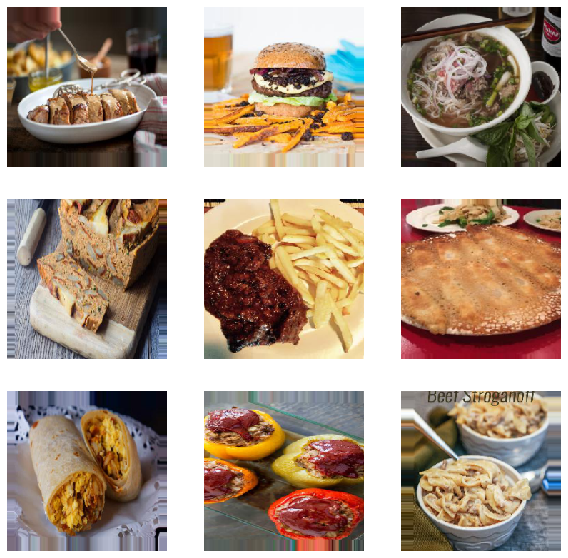

In [41]:
# plot a few images

plt.figure(figsize = (10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)  # create a 3x3 grid
    batch = next(train_images)  # get a batch of images
    img = batch[0]  #  take list of images out of the tuple
    img = img[0, :, :, :]  # grab first image from batch
    plt.axis('off')
    plt.imshow(img)

In [79]:
train_images.__dict__.keys()
np.array(train_images.classes)

array([79, 61, 40, ..., 55, 13, 16])

## Creating the base model (mobilenet v2)

MobileNet v2 is pre-trained on ImageNet (1.4 images, 1000 classes).

First we need to pick which layer of MobileNetv2 we will use for feature extraction. The very last classification layer (i.e. the 'top' layer) is not very useful since these features might be too specific.

Instead we will use the common practice to depend on the very last layer before the flatten operation, also called the 'bottleneck layer'. The bottleneck layer features retain more generality as compared to the final/top layer.

We instantiate a MobileNet v2 model pre-loaded with the weights trained on Imagenet. By speficying include_top = False, we load a network that doesn't include the classification layers at the top, which is ideal for feature extraction.

In [44]:
# create base model from pre-trained mobilenet v2
IMG_SHAPE = (IMG_SIZE) + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape = IMG_SHAPE,
                                              include_top = False,
                                              weights = 'imagenet')

In [43]:
IMG_SHAPE

(224, 224, 3)

This feature extractor converts each 224x224x3 image into a 7x7x1280 block of features. As an example, we can apply it to a batch of images:

In [45]:
image_batch, label_batch = next(train_images)
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 7, 7, 1280)


In [47]:
label_batch.shape

(32, 80)

## Feature Extraction

In [48]:
base_model.trainable = False # we prevent the weights from being updated during training
# taking a look at our base model architecture:
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 112, 112, 32) 864         input_3[0][0]                    
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 112, 112, 32) 128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, 112, 112, 32) 0           bn_Conv1[0][0]                   
_______________________________________________________________________________

### Adding a classification head

To generate predictions from the block of features, we average over the 7x7 spatial locations using a tf.keras.layers.GlobalAveragePooling2D layer to convert the features to a single 1280-element vector per image.

In [49]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


Now we apply a tf.keras.layers.Dense layer to convert these features into class predictions per image. We don't need an activation function here because this prediction will be treated as a logit

In [50]:
prediction_layer = tf.keras.layers.Dense(80)
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 80)


We build a model by chaining together the data augmentation, rescaling, base_model, and feature extractor layers using the Keras Functional API. We use training = False as our model contains a BatchNormalization layer

In [51]:
inputs = tf.keras.Input(shape=(IMG_SHAPE))
x = base_model(inputs, training=False) # generate base model, make sure we don't update our learned batchnorm params
x = global_average_layer(x) # average the features for each input
x = tf.keras.layers.Dropout(0.2)(x) # use dropout so we don't overfit
outputs = prediction_layer(x) # our dense prediction layer
model = tf.keras.Model(inputs, outputs)

In [52]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(lr=base_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              # loss=tf.nn.softmax_cross_entropy_with_logits(),
              metrics=['accuracy']) # check if we are using the corrrect loss function here!

In [54]:
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
mobilenetv2_1.00_224 (Functi (None, 7, 7, 1280)        2257984   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1280)              0         
_________________________________________________________________
dropout (Dropout)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 80)                102480    
Total params: 2,360,464
Trainable params: 102,480
Non-trainable params: 2,257,984
_________________________________________________________________


### Training the model

In [55]:
initial_epochs = 10 # setting number of training epochs

loss0, accuracy0 = model.evaluate(validation_images) # accuracy and loss with no training

192/192 [==============================] - 134s 689ms/step - loss: 4.8475 - accuracy: 0.0087


In [56]:
print('initial loss: {:.2f}'.format(loss0))
print('initial accuracy: {:.2f}'.format(accuracy0))

initial loss: 4.85
initial accuracy: 0.01


In [61]:
# without class weights
history = model.fit(train_images,
                    epochs=initial_epochs,
                    validation_data=validation_images)

Epoch 1/10
766/766 [==============================] - 608s 791ms/step - loss: 3.9726 - accuracy: 0.1001 - val_loss: 3.2935 - val_accuracy: 0.2414
Epoch 2/10
766/766 [==============================] - 602s 786ms/step - loss: 3.1030 - accuracy: 0.2610 - val_loss: 2.7959 - val_accuracy: 0.3419
Epoch 3/10
766/766 [==============================] - 605s 789ms/step - loss: 2.7184 - accuracy: 0.3409 - val_loss: 2.5647 - val_accuracy: 0.3839
Epoch 4/10
766/766 [==============================] - 601s 784ms/step - loss: 2.5103 - accuracy: 0.3833 - val_loss: 2.4263 - val_accuracy: 0.4067
Epoch 5/10
766/766 [==============================] - 600s 782ms/step - loss: 2.3790 - accuracy: 0.4083 - val_loss: 2.3391 - val_accuracy: 0.4288
Epoch 6/10
766/766 [==============================] - 609s 795ms/step - loss: 2.2699 - accuracy: 0.4328 - val_loss: 2.2709 - val_accuracy: 0.4443
Epoch 7/10
766/766 [==============================] - 602s 786ms/step - loss: 2.1911 - accuracy: 0.4499 - val_loss: 2.2268 -

### Generating the learning curves

Text(0.5, 1.0, 'Training and Validation Accuracy')

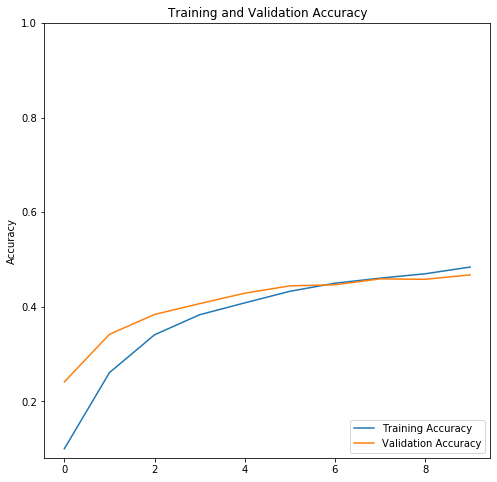

In [64]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
# plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

# plt.subplot(2, 1, 2)
# plt.plot(loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.ylabel('Cross Entropy')
# plt.ylim([0,1.0])
# plt.title('Training and Validation Loss')
# plt.xlabel('epoch')
# plt.show()